# Python ile Veri Bilimi: Dönem Sonu Projesi
## Hata Maliyeti Odaklı (Cost-Sensitive) Müşteri Kaybı (Churn) Analitiği ve Karar Optimizasyonu

**Proje Teması:**  Hata Maliyeti Odaklı Müşteri/Kredi Analitiği
**Hazırlayan:** Fırat Çakmak

### Kullanılan Veri Kaynakları ve Erişim Linkleri:
1. **Banka Müşteri Davranış ve Churn Veri Seti (GitHub - 10,000 Müşteri):**
   * Banka İşlem Bilgileri: [Bank_Churn.csv](https://raw.githubusercontent.com/purna-chandrasekhar/Bank-Customer-Behavior-and-Churn-Analysis/main/data/Bank_Churn.csv)
   * Müşteri Profil Bilgileri: [CustomerInfo.csv](https://raw.githubusercontent.com/purna-chandrasekhar/Bank-Customer-Behavior-and-Churn-Analysis/main/data/CustomerInfo.csv)
   * Ülke Bilgileri: [Geography.csv](https://raw.githubusercontent.com/purna-chandrasekhar/Bank-Customer-Behavior-and-Churn-Analysis/main/data/Geography.csv)
   * Cinsiyet Bilgileri: [Gender.csv](https://raw.githubusercontent.com/purna-chandrasekhar/Bank-Customer-Behavior-and-Churn-Analysis/main/data/Gender.csv)
2. **Makroekonomik Göstergeler (St. Louis Fed - FRED):**
   * Euro Bölgesi Enflasyon Endeksi (CPI): [CP0000EZ19M086NEST](https://fred.stlouisfed.org/series/CP0000EZ19M086NEST)
   * Avrupa Merkez Bankası (ECB) Mevduat Faiz Oranları: [ECBDFR](https://fred.stlouisfed.org/series/ECBDFR)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings('ignore')


C:\Users\mavi\Desktop\Python ödevi\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Adım 1: Veri Harmanlama (Data Fusion)

In [2]:
# 1. Müşteri Verilerinin Yüklenmesi
df_churn = pd.read_csv('data/Bank_Churn.csv')
df_info = pd.read_csv('data/CustomerInfo.csv')
df_geo = pd.read_csv('data/Geography.csv')
df_gen = pd.read_csv('data/Gender.csv')

# 2. Makroekonomik Verilerin Yüklenmesi
df_cpi = pd.read_csv('data/CP0000EZ19M086NEST.csv')
df_ecb = pd.read_csv('data/ECBDFR.csv')

# 3. Tarih Sütunlarının Dönüştürülmesi
df_info['Bank DOJ'] = pd.to_datetime(df_info['Bank DOJ'], format='%d-%m-%Y')
df_cpi['DATE'] = pd.to_datetime(df_cpi['DATE'])
df_ecb['DATE'] = pd.to_datetime(df_ecb['DATE'])

# 4. ECB Günlük Faiz Oranlarının Aylık Ortalamaya Dönüştürülmesi
df_ecb_monthly = df_ecb.groupby(df_ecb['DATE'].dt.to_period('M'))['ECBDFR'].mean().reset_index()
df_ecb_monthly['DATE'] = df_ecb_monthly['DATE'].dt.to_timestamp()

# 5. Müşteri Verilerinin Birleştirilmesi (Internal Merge)
df_merged = pd.merge(df_churn, df_info, on='CustomerId', how='inner')
df_merged = pd.merge(df_merged, df_geo, on='GeographyID', how='inner')
df_merged = pd.merge(df_merged, df_gen, on='GenderID', how='inner')

# 6. Katılım Tarihine Göre Makroekonomik Verilerin Birleştirilmesi (Data Fusion)
df_merged['DOJ_YearMonth'] = df_merged['Bank DOJ'].dt.to_period('M').dt.to_timestamp()

df_merged = pd.merge(df_merged, df_cpi, left_on='DOJ_YearMonth', right_on='DATE', how='left').drop(columns=['DATE'])
df_merged.rename(columns={'CP0000EZ19M086NEST': 'Inflation_At_Joining'}, inplace=True)

df_merged = pd.merge(df_merged, df_ecb_monthly, left_on='DOJ_YearMonth', right_on='DATE', how='left').drop(columns=['DATE'])
df_merged.rename(columns={'ECBDFR': 'Interest_Rate_At_Joining'}, inplace=True)

print(f"Veri Harmanlama Başarılı! Birleştirilmiş Veri Boyutu: {df_merged.shape}")
print(df_merged[['CustomerId', 'Surname', 'GeographyLocation', 'Bank DOJ', 'Inflation_At_Joining', 'Interest_Rate_At_Joining']].head(3))


Veri Harmanlama Başarılı! Birleştirilmiş Veri Boyutu: (10000, 19)
   CustomerId   Surname GeographyLocation   Bank DOJ  Inflation_At_Joining  \
0    15634602  Hargrave            France 2016-03-23                 77.67   
1    15647311      Hill             Spain 2018-10-09                 81.34   
2    15619304      Onio            France 2019-03-25                 81.09   

   Interest_Rate_At_Joining  
0                 -0.351613  
1                 -0.400000  
2                 -0.400000  


### Adım 2: İş Mantığına Dayalı Özellik Mühendisliği (Feature Engineering)

In [3]:
# İş Mantığına Dayalı Özellik Mühendisliği (En az 3 Değişken)

# Değişken 1: Finansal Kaldıraç Oranı (Bakiye / Maaş)
df_merged['Balance_Salary_Ratio'] = df_merged['Balance'] / (df_merged['EstimatedSalary'] + 1)

# Değişken 2: Hizmet Başına Tenür (Kullanılan Ürün Sayısı / Tenür)
df_merged['Products_per_Tenure'] = df_merged['NumOfProducts'] / (df_merged['Tenure'] + 1)

# Değişken 3: Makroekonomik Stres Endeksi (Katılım Tarihindeki Faiz x Enflasyon)
df_merged['Macro_Stress_Index'] = df_merged['Interest_Rate_At_Joining'] * df_merged['Inflation_At_Joining']

# Değişken 4: Yaş ve Aktivite Etkileşimi (Yaş x Aktif Üyelik)
df_merged['Age_Activity_Index'] = df_merged['Age'] * df_merged['IsActiveMember']

print("Özellik Mühendisliği Tamamlandı. Yeni Değişkenlerin İstatistikleri:")
print(df_merged[['Balance_Salary_Ratio', 'Products_per_Tenure', 'Macro_Stress_Index', 'Age_Activity_Index']].describe())


Özellik Mühendisliği Tamamlandı. Yeni Değişkenlerin İstatistikleri:
       Balance_Salary_Ratio  Products_per_Tenure  Macro_Stress_Index  \
count          10000.000000         10000.000000        10000.000000   
mean               3.790150             0.273408          -33.065029   
std              100.055758             0.122965            3.306305   
min                0.000000             0.125000          -40.965000   
25%                0.000000             0.166667          -32.656000   
50%                0.746998             0.250000          -32.280000   
75%                1.514002             0.333333          -31.584000   
max             9770.883148             1.000000          -22.974000   

       Age_Activity_Index  
count        10000.000000  
mean            20.496600  
std             21.585365  
min              0.000000  
25%              0.000000  
50%             23.000000  
75%             38.000000  
max             92.000000  


### Adım 3: Keşifçi Veri Analizi (EDA)

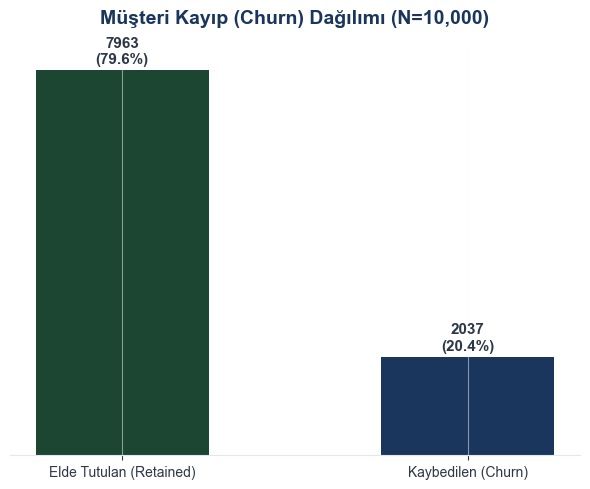

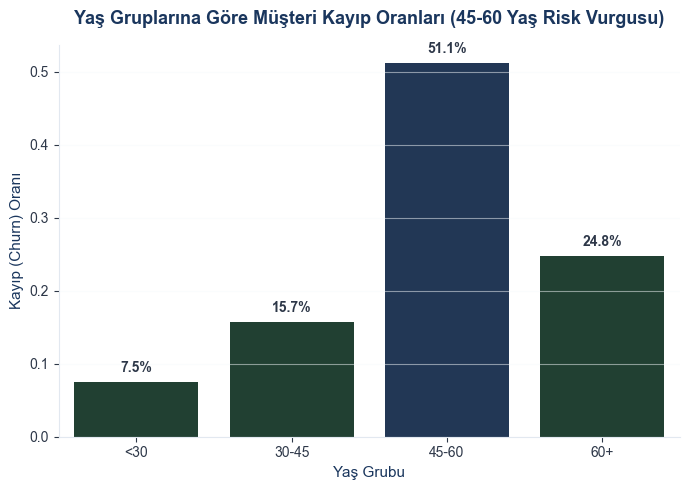

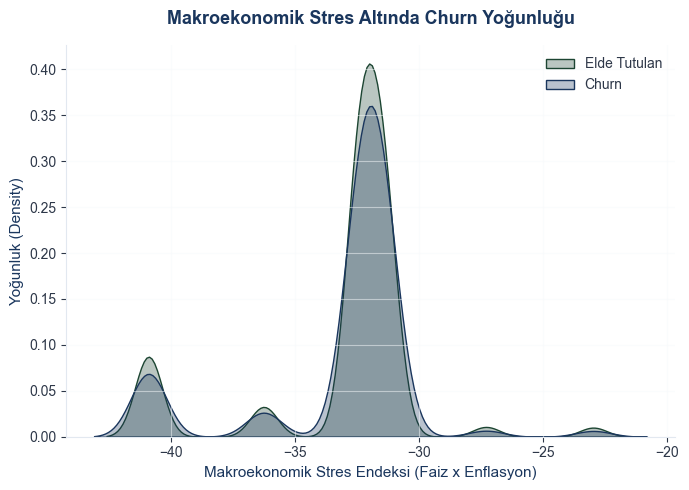

In [ ]:


import matplotlib as mpl
mpl.style.use('default')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#E2E8F0'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#F7FAFC'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2D3748'
plt.rcParams['axes.labelcolor'] = '#2D3748'
plt.rcParams['xtick.color'] = '#2D3748'
plt.rcParams['ytick.color'] = '#2D3748'
plt.rcParams['legend.edgecolor'] = '#E2E8F0'

NAVY = '#1A365D'
GREEN = '#1C4532'
LIGHT_GRAY = '#E2E8F0'

# Grafik 1: Müşteri Kayıp Dağılımı (Minimalist Churn Dağılımı)
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df_merged['Exited'].value_counts()
bars = ax.bar(['Elde Tutulan (Retained)', 'Kaybedilen (Churn)'], churn_counts, color=[GREEN, NAVY], width=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}\n({height/len(df_merged)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2D3748')
plt.title('Müşteri Kayıp (Churn) Dağılımı (N=10,000)', fontsize=14, fontweight='bold', color=NAVY, pad=20)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# Grafik 2: Yaş Gruplarına Göre Churn Oranları
df_merged['Age_Group'] = pd.cut(df_merged['Age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])
age_churn = df_merged.groupby('Age_Group')['Exited'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='Age_Group', y='Exited', data=age_churn, palette=[GREEN, GREEN, NAVY, GREEN], ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Kayıp (Churn) Oranı', fontsize=11, color=NAVY)
ax.set_xlabel('Yaş Grubu', fontsize=11, color=NAVY)
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.title('Yaş Gruplarına Göre Müşteri Kayıp Oranları (45-60 Yaş Risk Vurgusu)', fontsize=13, fontweight='bold', color=NAVY, pad=15)
plt.tight_layout()
plt.savefig('churn_by_age.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# Grafik 3: Makroekonomik Stres Endeksi Churn Analizi
fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(data=df_merged[df_merged['Exited']==0], x='Macro_Stress_Index', color=GREEN, label='Elde Tutulan', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(data=df_merged[df_merged['Exited']==1], x='Macro_Stress_Index', color=NAVY, label='Churn', fill=True, alpha=0.3, ax=ax)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Makroekonomik Stres Endeksi (Faiz x Enflasyon)', fontsize=11, color=NAVY)
ax.set_ylabel('Yoğunluk (Density)', fontsize=11, color=NAVY)
plt.legend(frameon=False)
plt.title('Makroekonomik Stres Altında Churn Yoğunluğu', fontsize=13, fontweight='bold', color=NAVY, pad=15)
plt.tight_layout()
plt.savefig('macro_stress_density.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()


### Adım 4: Modelleme ve Hiperparametre Optimizasyonu (LightGBM)

In [5]:
# Modelleme Öncesi Veri Hazırlığı ve LightGBM Eğitimi

# Kategorik değişkenlerin encode edilmesi ve gereksiz sütunların çıkarılması
drop_cols = ['CustomerId', 'Surname', 'GeographyID', 'GenderID', 'Bank DOJ', 'DOJ_YearMonth', 'Age_Group']
df_model = df_merged.drop(columns=drop_cols)

# One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['GeographyLocation', 'GenderCategory'], drop_first=True)

# Bağımlı ve Bağımsız Değişkenler
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

# Train-Test Bölünmesi (%80 Train, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ölçeklendirme (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# LightGBM Sınıflandırıcı Kurulumu ve Hiperparametre Optimizasyonu
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63]
}

grid_search = GridSearchCV(lgb_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_df, y_train)

best_model = grid_search.best_estimator_
print("En İyi Hiperparametreler:", grid_search.best_params_)

# Test Seti Tahminleri
y_pred = best_model.predict(X_test_df)
y_pred_proba = best_model.predict_proba(X_test_df)[:, 1]

# Standart Değerlendirme Metrikleri
print("\n--- Standart Değerlendirme Raporu (%50 Eşik Değeri) ---")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_pred_proba):.4f}")


En İyi Hiperparametreler: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 15}

--- Standart Değerlendirme Raporu (%50 Eşik Değeri) ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Confusion Matrix:
 [[1531   62]
 [ 212  195]]
ROC-AUC Skoru: 0.8678


### Adım 5: Açıklanabilir Yapay Zeka (XAI) - SHAP Analizleri

SHAP değerleri hesaplanıyor...


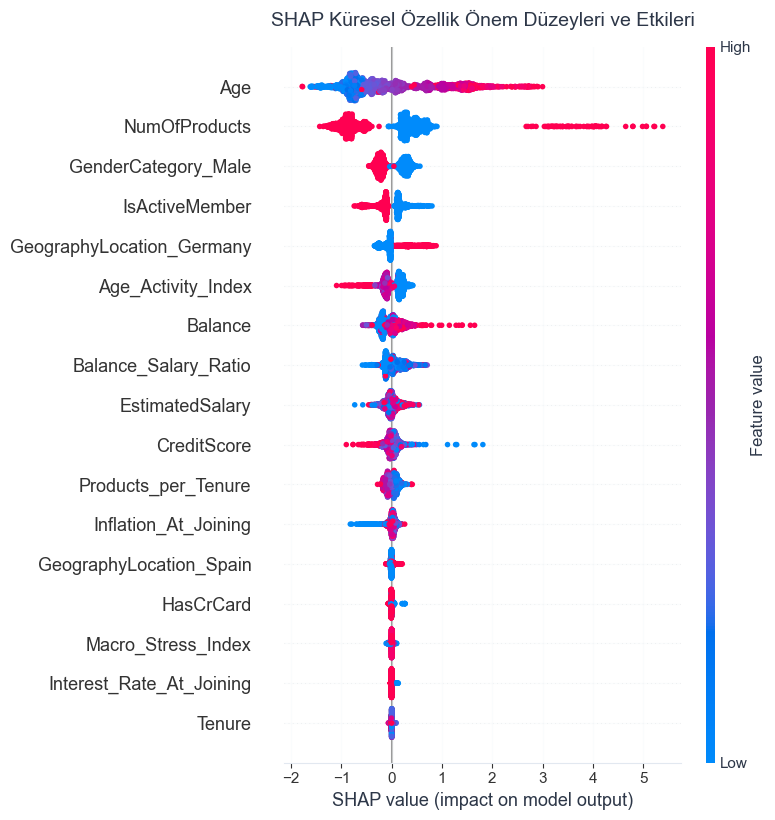

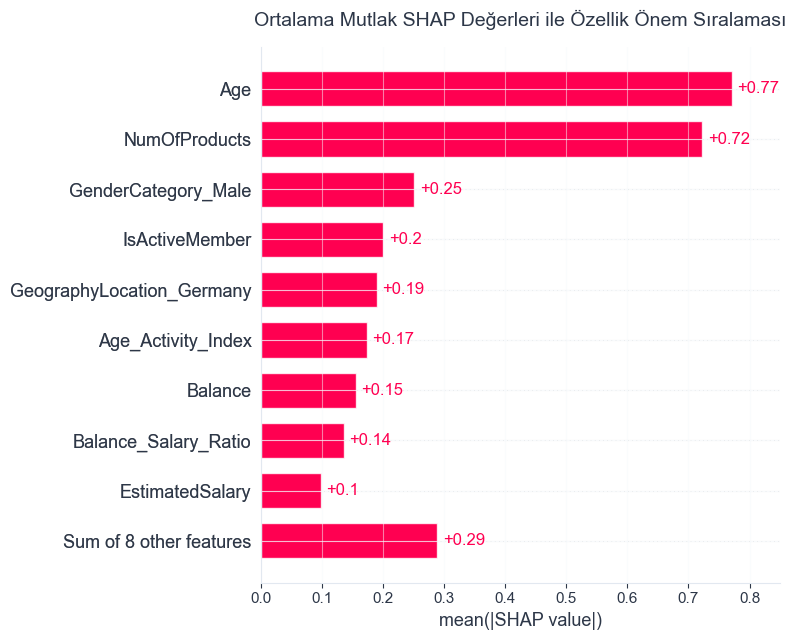

<Figure size 800x500 with 0 Axes>

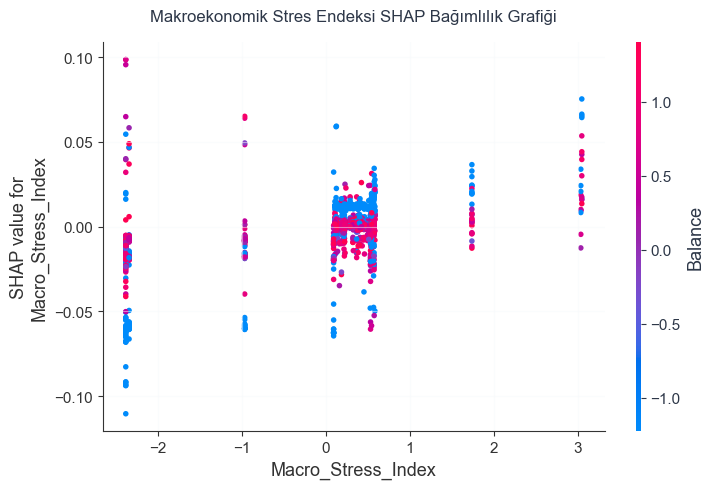

In [6]:
# Açıklanabilir Yapay Zeka (XAI) - SHAP Analizi
print("SHAP değerleri hesaplanıyor...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_df)

# SHAP Özet Grafiği (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP Küresel Özellik Önem Düzeyleri ve Etkileri", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# SHAP Bar Grafiği (Bar Plot)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, show=False)
plt.title("Ortalama Mutlak SHAP Değerleri ile Özellik Önem Sıralaması", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

# Enflasyon / Faiz Etkileşimine Yönelik SHAP Bağımlılık Grafiği (Dependency Plot)
plt.figure(figsize=(8, 5))
shap.dependence_plot("Macro_Stress_Index", shap_values.values, X_test_df, show=False)
plt.title("Makroekonomik Stres Endeksi SHAP Bağımlılık Grafiği", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()


### Adım 6: Maliyet/Fayda Simülasyonu ve Karar Eşiği Optimizasyonu

Teorik Optimal Karar Eşiği (p*): 0.1333 (%13.33)
Müdahale Yapılmayan Baz Senaryo Toplam Maliyeti (2000 Müşteri): 407,000.00 EUR
Deneysel Optimal Karar Eşiği: %13.00
Deneysel Optimal Eşikteki Toplam Maliyet: 231,050.00 EUR
Baz Senaryoya Göre Net Tasarruf: 175,950.00 EUR
Standart %50 Eşikteki Toplam Maliyet: 286,450.00 EUR
Standart %50 Eşikteki Net Tasarruf: 120,550.00 EUR
Optimal Eşiğe Geçilerek Standart %50 Eşiğe Göre Ekstra Kazanç: 55,400.00 EUR (Aynı test kümesinde)


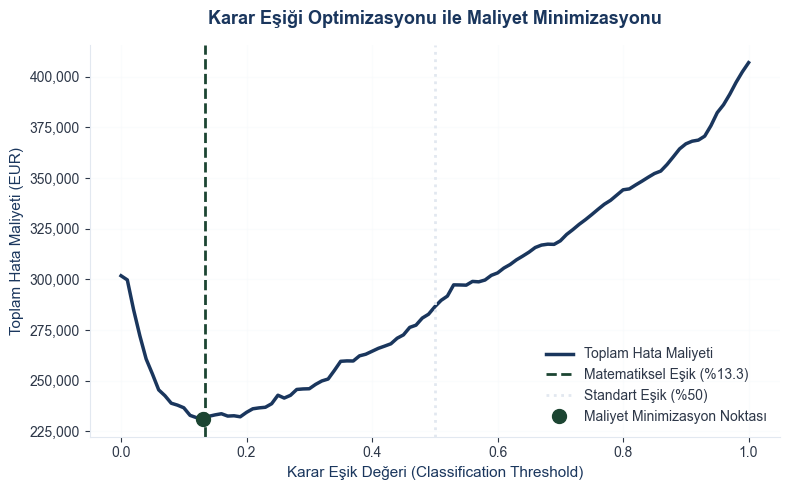

In [ ]:
# Maliyet/Fayda Simülasyonu ve Karar Eşiği Optimizasyonu

# İşletme Finansal Parametreleri:
# C_I = 100 EUR (Müşteriyi tutmak için verilen nakit/promosyon teklifi - False Positive Maliyeti)
# V = 1000 EUR (Müşterinin yıllık net Lifetime Value (LTV) kaybı - False Negative Maliyeti)
# r = 0.75 (Kampanyaya maruz kalan churn riski yüksek müşterinin ikna olma oranı)

C_I = 100
V = 1000
r = 0.75

# Matematiksel Eşik Hesaplaması:
# p* = C_I / (r * V) = 100 / (0.75 * 1000) = 0.1333
optimal_threshold = C_I / (r * V)
print(f"Teorik Optimal Karar Eşiği (p*): {optimal_threshold:.4f} (%{optimal_threshold*100:.2f})")

# Eşik Değerlerinin Simüle Edilmesi
thresholds = np.linspace(0, 1, 101)
total_costs = []
total_savings = []

# Baz Senaryo: Müdahale Yok (Hiçbir Churn Tahmini Yapılmaz ve Müşteri Kurtarılmaya Çalışılmaz)
# Bu durumda kaybedilen her müşteri bankaya 1000 EUR zarar yazar.
base_cost = sum(y_test == 1) * V
print(f"Müdahale Yapılmayan Baz Senaryo Toplam Maliyeti (2000 Müşteri): {base_cost:,.2f} EUR")

for t in thresholds:
    # Eşik değerine göre tahminler
    y_pred_t = (y_pred_proba >= t).astype(int)
    
    # Hata Matrisi Değerleri
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    # Finansal Hata Maliyeti Matrisi Formülü:
    # Cost = TP * Cost_TP + FP * Cost_FP + FN * Cost_FN + TN * Cost_TN
    # Cost_TP = C_I + (1 - r)*V = 100 + 0.25*1000 = 350 EUR
    # Cost_FP = C_I = 100 EUR
    # Cost_FN = V = 1000 EUR
    # Cost_TN = 0 EUR
    
    cost_tp = C_I + (1 - r) * V
    cost_fp = C_I
    cost_fn = V
    cost_tn = 0
    
    total_cost_t = (tp * cost_tp) + (fp * cost_fp) + (fn * cost_fn) + (tn * cost_tn)
    total_costs.append(total_cost_t)
    
    # Sağlanan tasarruf: Baz Maliyet - Mevcut Eşik Maliyeti
    saving = base_cost - total_cost_t
    total_savings.append(saving)

# En iyi deneysel eşiğin bulunması
min_cost_idx = np.argmin(total_costs)
best_exp_threshold = thresholds[min_cost_idx]
min_cost = total_costs[min_cost_idx]
max_saving = total_savings[min_cost_idx]

print(f"Deneysel Optimal Karar Eşiği: %{best_exp_threshold*100:.2f}")
print(f"Deneysel Optimal Eşikteki Toplam Maliyet: {min_cost:,.2f} EUR")
print(f"Baz Senaryoya Göre Net Tasarruf: {max_saving:,.2f} EUR")

# Standart %50 Eşikteki Performans
idx_50 = np.where(np.isclose(thresholds, 0.50))[0][0]
cost_50 = total_costs[idx_50]
saving_50 = total_savings[idx_50]
print(f"Standart %50 Eşikteki Toplam Maliyet: {cost_50:,.2f} EUR")
print(f"Standart %50 Eşikteki Net Tasarruf: {saving_50:,.2f} EUR")

# Karşılaştırmalı Finansal Katma Değer
net_improvement = cost_50 - min_cost
print(f"Optimal Eşiğe Geçilerek Standart %50 Eşiğe Göre Ekstra Kazanç: {net_improvement:,.2f} EUR (Aynı test kümesinde)")

# Grafik: Karar Eşiği vs Toplam Finansal Maliyet
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, total_costs, color=NAVY, linewidth=2.5, label='Toplam Hata Maliyeti')
ax.axvline(optimal_threshold, color=GREEN, linestyle='--', linewidth=2, label=f'Matematiksel Eşik (%{optimal_threshold*100:.1f})')
ax.axvline(0.50, color='#E2E8F0', linestyle=':', linewidth=2, label='Standart Eşik (%50)')
ax.plot(best_exp_threshold, min_cost, 'o', color=GREEN, markersize=10, label='Maliyet Minimizasyon Noktası')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Karar Eşik Değeri (Classification Threshold)', fontsize=11, color=NAVY)
ax.set_ylabel('Toplam Hata Maliyeti (EUR)', fontsize=11, color=NAVY)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.title('Karar Eşiği Optimizasyonu ile Maliyet Minimizasyonu', fontsize=13, fontweight='bold', color=NAVY, pad=15)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()
